In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt  

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [5]:
import pandas as pd
import csv

df = pd.read_csv(
    "Mytable for purchase pattern analysis.csv",
    engine="python",
    quoting=csv.QUOTE_NONE,
    on_bad_lines="skip",
    encoding="latin1"
)

In [7]:
df.head()

,BillNo,Itemname,Quantity,Present_Date,Price,CustomerID,Country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,1/12/2010 8:26,2.55,17850.0,United Kingdom
1,536365,WHITE METAL LANTERN,6,1/12/2010 8:26,3.39,17850.0,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,1/12/2010 8:26,2.75,17850.0,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,1/12/2010 8:26,3.39,17850.0,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,1/12/2010 8:26,3.39,17850.0,United Kingdom


In [8]:
df.isnull().sum()

BillNo               0
Itemname          1455
Quantity             0
Present_Date         0
Price                0
CustomerID      132353
Country              0
dtype: int64

In [5]:
df.describe()

,Quantity,Price,CustomerID
count,517409.000000,517409.000000,385056.000000
mean,9.984301,3.839509,15316.990394
std,115.797270,42.087050,1722.302621
min,-9600.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13949.000000
50%,3.000000,2.080000,15265.000000
75%,10.000000,4.130000,16837.000000
max,74215.000000,13541.330000,18287.000000


In [9]:
df.describe(include='O')

C:\Users\Dhanraj\AppData\Local\Temp\ipykernel_18132\2537740217.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='O')


,BillNo,Itemname,Present_Date,Country
count,517409,515954,517409,517409
unique,21642,4113,19626,30
top,573585,WHITE HANGING HEART T-LIGHT HOLDER,31-10-2011 14:41,United Kingdom
freq,1102,2269,1102,483140


In [11]:
df.duplicated().sum()

np.int64(5176)

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [7]:
x = df[['BillNo', 'Itemname', 'Quantity', 'Price', 'CustomerID','Present_Date']]

In [8]:
x

,BillNo,Itemname,Quantity,Price,CustomerID,Present_Date
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,1/12/2010 8:26
1,536365,WHITE METAL LANTERN,6,3.39,17850.0,1/12/2010 8:26
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,1/12/2010 8:26
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,1/12/2010 8:26
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,1/12/2010 8:26
...,...,...,...,...,...,...
517404,581587,PACK OF 20 SPACEBOY NAPKINS,12,0.85,12680.0,9/12/2011 12:50
517405,581587,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,9/12/2011 12:50
517406,581587,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,9/12/2011 12:50
517407,581587,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680.0,9/12/2011 12:50


In [9]:
x.isnull().sum()

BillNo               0
Itemname          1455
Quantity             0
Price                0
CustomerID      132353
Present_Date         0
dtype: int64

In [10]:
x = x.dropna(subset=['CustomerID'])

In [11]:
x = x[x['Quantity'] > 0]

In [12]:
x = x[x['Price'] > 0]

In [13]:
x = x.drop_duplicates()

In [14]:
x['Present_Date'] = pd.to_datetime(
    x['Present_Date'],
    dayfirst=True,
    errors='coerce'
)

In [15]:
x['Present_Date'].isnull().sum()

np.int64(218755)

In [16]:
x = x.dropna(subset=['Present_Date'])

In [17]:
x['Revenue'] = x['Quantity'] * x['Price']

In [18]:
x

,BillNo,Itemname,Quantity,Price,CustomerID,Present_Date,Revenue
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,2010-12-01 08:26:00,15.30
1,536365,WHITE METAL LANTERN,6,3.39,17850.0,2010-12-01 08:26:00,20.34
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,2010-12-01 08:26:00,22.00
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,2010-12-01 08:26:00,20.34
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,2010-12-01 08:26:00,20.34
...,...,...,...,...,...,...,...
517404,581587,PACK OF 20 SPACEBOY NAPKINS,12,0.85,12680.0,2011-12-09 12:50:00,10.20
517405,581587,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,2011-12-09 12:50:00,12.60
517406,581587,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,2011-12-09 12:50:00,16.60
517407,581587,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680.0,2011-12-09 12:50:00,16.60


In [19]:
basket = x.groupby(['BillNo', 'Itemname'])['Quantity'] \
           .sum().unstack().fillna(0)

In [20]:
basket = basket.map(lambda x: 1 if x > 0 else 0)

In [21]:
pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [22]:
from mlxtend.frequent_patterns import apriori, association_rules

In [23]:
frequent_items = apriori(basket, 
                         min_support=0.02, 
                         use_colnames=True)

C:\Users\Dhanraj\AppData\Roaming\Python\Python313\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [24]:
rules = association_rules(frequent_items, 
                          metric="lift", 
                          min_threshold=1)

In [25]:
strong_rules = rules[(rules['confidence'] > 0.5) & 
                     (rules['lift'] > 1)]

<Axes: xlabel='Itemname'>

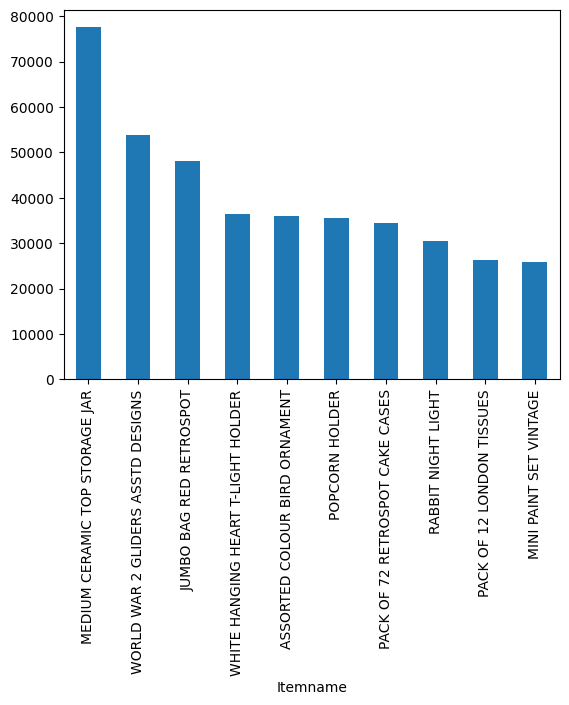

In [26]:
top_products = df.groupby('Itemname')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')

<Axes: xlabel='Itemname'>

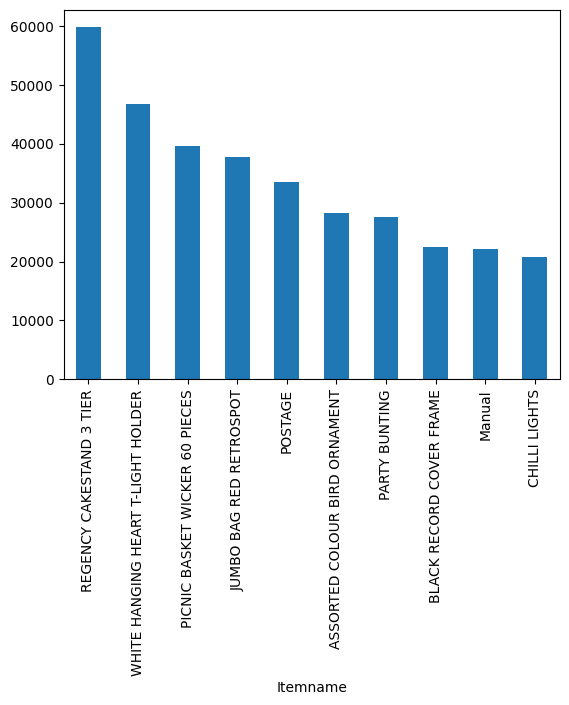

In [27]:
top_revenue = x.groupby('Itemname')['Revenue'].sum().sort_values(ascending=False).head(10)

top_revenue.plot(kind='bar')

<Axes: xlabel='CustomerID'>

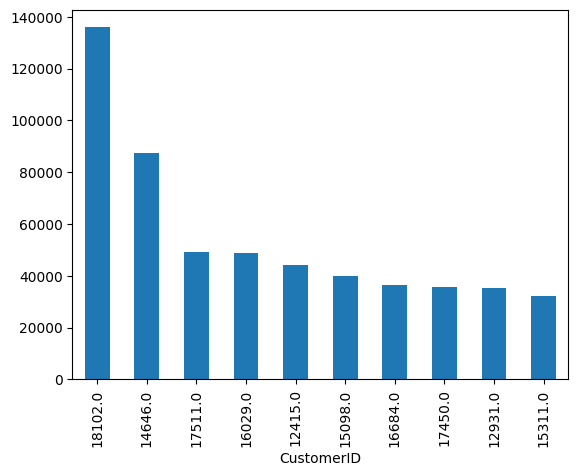

In [28]:
x.groupby('CustomerID')['Revenue'].sum() \
  .sort_values(ascending=False) \
  .head(10) \
  .plot(kind='bar')

<Axes: xlabel='Month'>

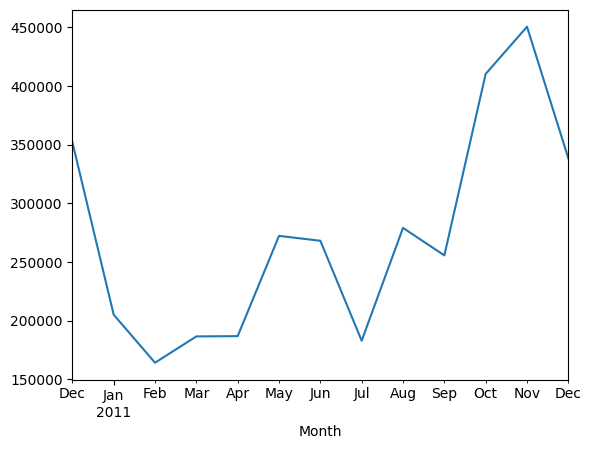

In [29]:
x['Month'] = x['Present_Date'].dt.to_period('M')

x.groupby('Month')['Revenue'].sum().plot()

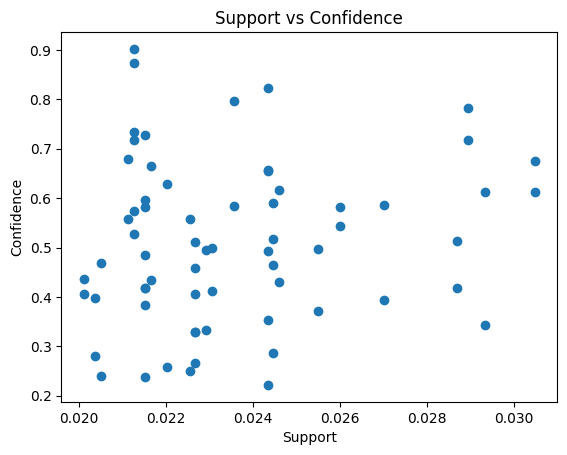

In [30]:
import matplotlib.pyplot as plt

plt.scatter(rules['support'], rules['confidence'])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()

In [31]:
x = x.dropna(subset=['CustomerID'])

In [34]:
x = x[x['Quantity'] > 0]

In [35]:
x = x[x['Price'] > 0]

In [38]:
x = x[~x['BillNo'].astype(str).str.startswith('C')]

In [41]:
x = x.drop_duplicates()

In [44]:
x['Present_Date'] = pd.to_datetime(x['Present_Date'], dayfirst=True)

In [45]:
x['Revenue'] = x['Quantity'] * x['Price']

In [46]:
x.to_csv("cleaned_reatail_data.csv", index=False)

In [48]:
x.to_csv(r"C:\Users\Dhanraj\Desktop\cleaned_retail_data.csv", index=False)

In [49]:
rules.to_csv("association_rules.csv", index=False)

In [55]:
x.to_csv(r"C:\Users\Dhanraj\Desktop\association_rules.csv", index=False)

In [58]:
rules[['antecedents','consequents','support','confidence','lift']] \
    .to_csv("association_rules.csv", index=False)

In [62]:
rules.to_csv(r"C:\Users\Dhanraj\Desktop\association_rules.csv", index=False)